# Figure 6: FCD-IFFL with Cancer — asymmetric vs cubic coupling

Two models sharing the same FCD-IFFL circuit:

$$
\frac{dA}{dt} = \beta_1\,u - \alpha_1\,A \qquad
\frac{dB}{dt} = \frac{\beta_2\,u}{A} - \alpha_2\,B
$$

$$B_{ss} = \frac{\beta_2\,\alpha_1}{\alpha_2\,\beta_1} \quad (\text{independent of } u \text{ — RPA})$$

**Model 1 — asymmetric (one-sided):**
$$\frac{dC}{dt} = C\bigl(c_1 - c_2\,\max(B_{ss} - B,\,0)\bigr)$$

Cancer decays only when $B < B_{ss}$; grows at rate $c_1$ otherwise.

**Model 2 — cubic (symmetric):**
$$\frac{dC}{dt} = C\bigl(c_1 - c_2\,(B_{ss} - B)^3\bigr)$$

Decay/growth depends on the signed cube of the deviation from $B_{ss}$.


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style
from rpa_control.paths import save_fig

set_style()
plt.rcParams['text.usetex'] = False

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# ── Shared parameters ─────────────────────────────────────────────────────────
PARAMS = dict(beta1=1.0, alpha1=5.0, beta2=5.0, alpha2=1.0)

C1 = 0.05   # cancer baseline growth rate
C2 = 1.0    # cancer kill/coupling rate

def B_ss(p=PARAMS):
    """Homeostatic steady state of B (independent of u — RPA)."""
    return p['beta2'] * p['alpha1'] / (p['alpha2'] * p['beta1'])

def steady_state(u, p=PARAMS):
    """Return (A_ss, B_ss) for input u."""
    A = p['beta1'] * u / p['alpha1']
    return A, B_ss(p)

B_SS = B_ss()
print(f"B_ss = {B_SS:.4f}  (independent of u — RPA confirmed)")


B_ss = 25.0000  (independent of u — RPA confirmed)


In [59]:
# ── ODE right-hand sides ─────────────────────────────────────────────────────

def fcd_rhs(t, state, u, p=PARAMS):
    """Shared FCD-IFFL subsystem: dA/dt and dB/dt."""
    A, B = state[0], state[1]
    u_val = u(t) if callable(u) else u
    dA = p['beta1'] * u_val - p['alpha1'] * A
    dB = p['beta2'] * u_val / A  - p['alpha2'] * B
    return dA, dB

def model1_rhs(t, state, u, p=PARAMS):
    """Model 1: asymmetric (one-sided) cancer coupling."""
    A, B, C = state
    dA, dB = fcd_rhs(t, state, u, p)
    dC = C * (C1 - C2 * max(B_SS - B, 0.0))
    return [dA, dB, dC]

def model2_rhs(t, state, u, p=PARAMS):
    """Model 2: cubic (symmetric) cancer coupling."""
    A, B, C = state
    dA, dB = fcd_rhs(t, state, u, p)
    dC = C * (C1 - C2 * (B_SS - B)**3)
    return [dA, dB, dC]

def simulate(rhs, u, t_span, y0=None, n_pts=2000, p=PARAMS):
    """Integrate a 3-state model."""
    if y0 is None:
        u0 = u(t_span[0]) if callable(u) else u
        A0, B0 = steady_state(u0, p)
        y0 = [A0, B0, 1.0]
    t_eval = np.linspace(*t_span, n_pts)
    return solve_ivp(lambda t, s: rhs(t, s, u, p),
                     t_span, y0, t_eval=t_eval,
                     method='Radau', rtol=1e-9, atol=1e-11)

def model3_rhs(t, state, u, p=PARAMS):
    """Model 3: linear (symmetric, no max) cancer coupling."""
    A, B, C = state
    dA, dB = fcd_rhs(t, state, u, p)
    dC = C * (C1 - C2 * (B_SS - B))
    return [dA, dB, dC]

MODELS = [
    ('Model 1 (asymmetric, max)', model1_rhs),
    ('Model 2 (cubic)',           model2_rhs),
    ('Model 3 (linear, no max)',  model3_rhs),
]

# ── Parameterised RHS (c1, c2 as explicit args, for scanning) ─────────────────
def m1_rhs(t, state, u, p, c1, c2):
    A, B, C = state
    dA, dB = fcd_rhs(t, state, u, p)
    dC = C * (c1 - c2 * max(B_ss(p) - B, 0.0))
    return [dA, dB, dC]

def m2_rhs(t, state, u, p, c1, c2):
    A, B, C = state
    dA, dB = fcd_rhs(t, state, u, p)
    dC = C * (c1 - c2 * (B_ss(p) - B)**3)
    return [dA, dB, dC]

def m3_rhs(t, state, u, p, c1, c2):
    A, B, C = state
    dA, dB = fcd_rhs(t, state, u, p)
    dC = C * (c1 - c2 * (B_ss(p) - B))
    return [dA, dB, dC]

model_fns = [
    ('Model 1\n(asymmetric)', m1_rhs),
    ('Model 2\n(cubic)',      m2_rhs),
    ('Model 3\n(linear)',     m3_rhs),
]

print("Models defined: model1/2/3_rhs  |  parameterised: m1/m2/m3_rhs")


Models defined: model1/2/3_rhs  |  parameterised: m1/m2/m3_rhs


/tmp/ipykernel_463590/1198608805.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


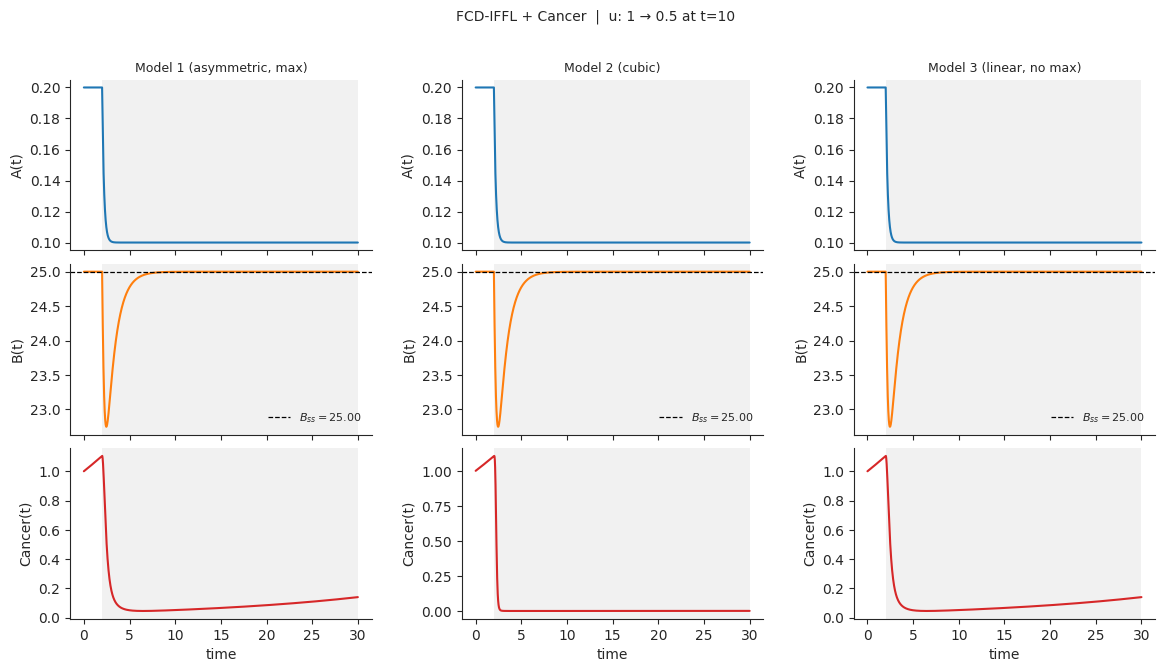

In [60]:
# ── Sanity check: step u = 1 → 0.5 ──────────────────────────────────────────
T_SWITCH = 2.0
T_END    = 30.0

A0, B0 = steady_state(1.0)
y0 = [A0, B0, 1.0]

def u_step(t):
    return 0.5 if t >= T_SWITCH else 1.0

models = MODELS

fig, axes = plt.subplots(3, 3, figsize=(14, 7), sharex=True,
                          gridspec_kw={'hspace': 0.08, 'wspace': 0.3})

ON_COLOR = 'lightgray'

for col, (name, rhs) in enumerate(models):
    sol = simulate(rhs, u_step, (0, T_END), y0=y0)
    t, A, B, C = sol.t, sol.y[0], sol.y[1], sol.y[2]

    for ax in axes[:, col]:
        ax.axvspan(T_SWITCH, T_END, color=ON_COLOR, alpha=0.3, lw=0)
        clean_ax(ax)

    axes[0, col].plot(t, A, color='C0', lw=1.5)
    axes[0, col].set_ylabel('A(t)')
    axes[0, col].set_title(name, fontsize=9)

    axes[1, col].plot(t, B, color='C1', lw=1.5)
    axes[1, col].axhline(B_SS, color='k', ls='--', lw=0.9,
                          label=f'$B_{{ss}}={B_SS:.2f}$')
    axes[1, col].set_ylabel('B(t)')
    axes[1, col].legend(fontsize=8, frameon=False)

    axes[2, col].plot(t, C, color='C3', lw=1.5)
    axes[2, col].set_ylabel('Cancer(t)')
    axes[2, col].set_xlabel('time')

fig.suptitle('FCD-IFFL + Cancer  |  u: 1 → 0.5 at t=10', fontsize=10)
plt.tight_layout()
plt.show()


In [73]:
def compare_treatments(rhs_fn, c1=C1, c2=C2, p=PARAMS,
                       t_pre=5.0, ramp_dur=10.0, treat_time=40.0,
                       u_base=1.0, u_primed=2.0, u_treat=0.5,
                       C_thresh=2.0, n_pts=3000, title=None):
    """
    Plot u(t), B(t), Cancer(t) for control and sensitization strategies.

    Timeline
    --------
    [0, t_pre)              : baseline u_base
    [t_pre, t_pre+ramp_dur) : sensitized ramps u_base → u_primed (control stays at u_base)
    [t_pre+ramp_dur, end)   : both abruptly switch to u_treat

    Parameters
    ----------
    rhs_fn     : parameterised RHS, signature (t, state, u_fn, params, c1, c2)
    c1, c2     : cancer kinetic parameters
    p          : IFFL parameter dict
    t_pre      : baseline warm-up before any intervention
    ramp_dur   : duration of the sensitization ramp (Stage 1)
    treat_time : duration of the treatment phase (Stage 2)
    u_base     : starting input value
    u_primed   : target of the sensitization ramp
    u_treat    : treatment input value (applied abruptly after ramp)
    """
    T_RAMP  = t_pre + ramp_dur
    T_END   = T_RAMP + treat_time
    t_eval  = np.linspace(0, T_END, n_pts)

    A0, B0 = steady_state(u_base, p)
    y0 = [A0, B0, 1.0]

    # ── input functions ───────────────────────────────────────────────────────
    def u_control(t):
        return u_treat if t >= t_pre else u_base

    def u_sensitized(t):
        if t < t_pre:
            return u_base
        elif t < T_RAMP:
            frac = (t - t_pre) / ramp_dur
            return u_base + (u_primed - u_base) * frac
        else:
            return u_treat

    # ── simulate ──────────────────────────────────────────────────────────────
    rhs_c = lambda t, s: rhs_fn(t, s, u_control,    p, c1, c2)
    rhs_s = lambda t, s: rhs_fn(t, s, u_sensitized, p, c1, c2)

    sol_c = solve_ivp(rhs_c, (0, T_END), y0, t_eval=t_eval,
                      method='Radau', rtol=1e-9, atol=1e-11)
    sol_s = solve_ivp(rhs_s, (0, T_END), y0, t_eval=t_eval,
                      method='Radau', rtol=1e-9, atol=1e-11)

    t = sol_c.t
    u_ctrl_arr = np.array([u_control(tt)    for tt in t])
    u_sens_arr = np.array([u_sensitized(tt) for tt in t])

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True,
                              gridspec_kw={'hspace': 0.08})

    for ax in axes:
        ax.axvspan(t_pre,  T_RAMP, color='#e8f4e8', alpha=0.8, lw=0)   # ramp phase
        ax.axvspan(T_RAMP, T_END,  color='lightgray', alpha=0.4, lw=0) # treat phase
        ax.axvline(t_pre,  color='k', ls=':', lw=0.8, alpha=0.5)
        ax.axvline(T_RAMP, color='k', ls=':', lw=0.8, alpha=0.5)
        sns.despine(ax=ax)

    # u(t)
    axes[0].plot(t, u_ctrl_arr, color='tomato',    lw=1.5, ls='--', label='control')
    axes[0].plot(t, u_sens_arr, color='steelblue', lw=1.5,          label='sensitized')
    axes[0].set_ylabel('u(t)')
    axes[0].legend(fontsize=8, frameon=False, loc='upper right')

    # B(t)
    axes[1].plot(t, sol_c.y[1], color='tomato',    lw=1.5, ls='--')
    axes[1].plot(t, sol_s.y[1], color='steelblue', lw=1.5)
    axes[1].axhline(B_SS, color='k', ls='--', lw=0.9,
                    label=f'$B_{{ss}}={B_SS:.2f}$')
    axes[1].set_ylabel('B(t)')
    axes[1].legend(fontsize=8, frameon=False)

    # Cancer(t)
    axes[2].plot(t, sol_c.y[2], color='tomato',    lw=1.5, ls='--')
    axes[2].plot(t, sol_s.y[2], color='steelblue', lw=1.5)
    axes[2].axhline(C_thresh, color='k', ls=':', lw=0.9, alpha=0.7,
                    label=f'threshold={C_thresh}')
    axes[2].set_ylabel('Cancer(t)')
    axes[2].set_xlabel('time')
    axes[2].legend(fontsize=8, frameon=False)

    _title = title or (f'Control (1→{u_treat}) vs Sensitization '
                       f'(1→{u_primed}→{u_treat})'
                       f'  |  $c_1$={c1}, $c_2$={c2}')
    axes[0].set_title(_title, fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

/tmp/ipykernel_463590/3395538987.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


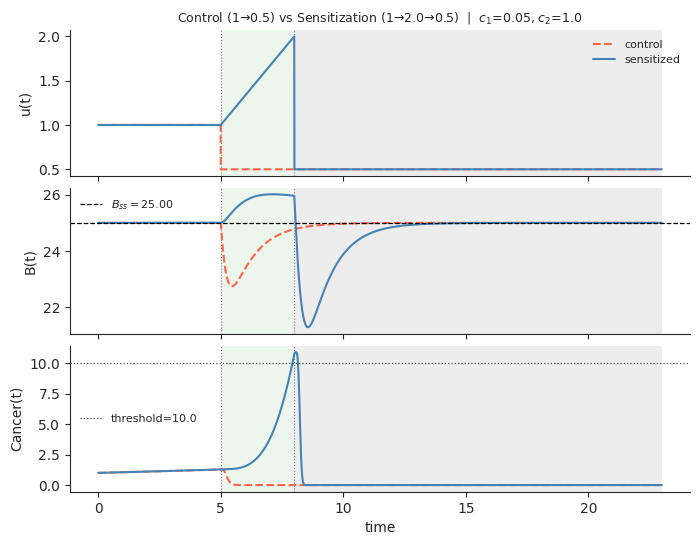

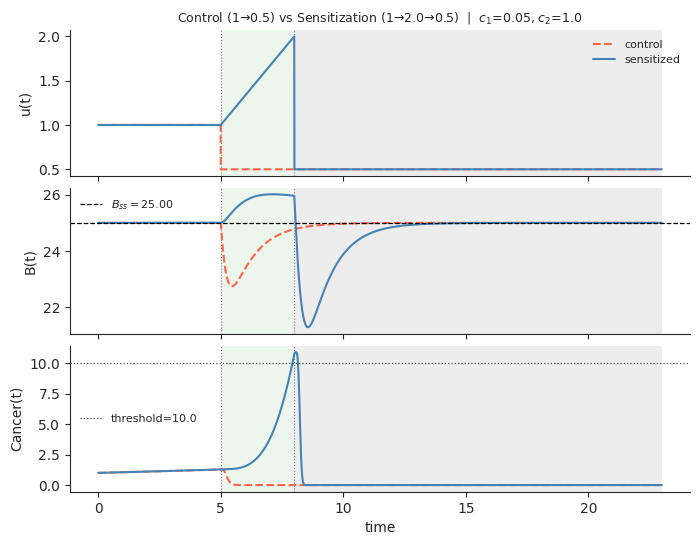

In [100]:
# model 1: asymmetric (max)
# model 2: cubic
# model 3: linear (sanity, sensitization should be exactly the same as control)
compare_treatments(m2_rhs, c1=0.05, c2=1.0, ramp_dur=3.0, treat_time=15.0)

Running heatmap scan (control vs sensitization 1→2→0.5)…
  Model 1 (asymmetric)… done
  Model 2 (cubic)… done
  Model 3 (linear)… done


/tmp/ipykernel_463590/1167818667.py:156: UserWarning: linewidths is ignored by contourf
  ax.contourf(c2_vals, c1_vals, ctrl_only.astype(float),
/tmp/ipykernel_463590/1167818667.py:161: UserWarning: linewidths is ignored by contourf
  ax.contourf(c2_vals, c1_vals, both_inf.astype(float),
/tmp/ipykernel_463590/1167818667.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


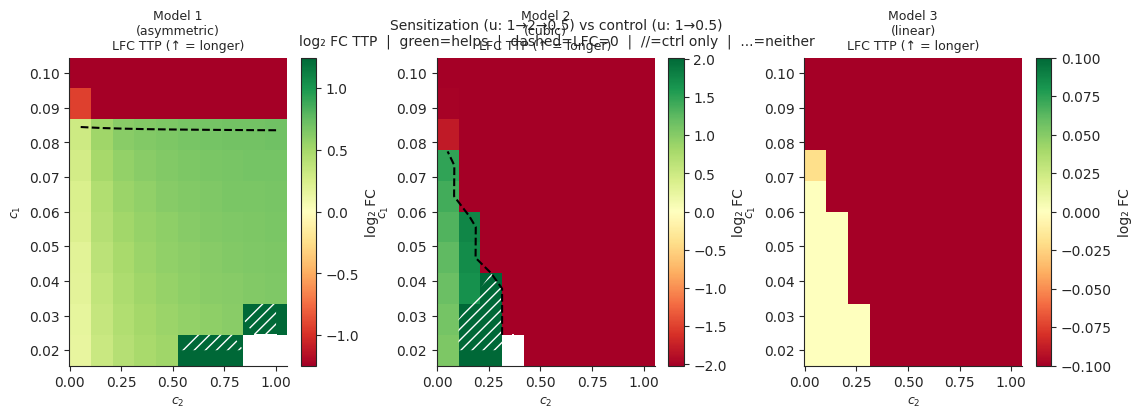

In [96]:
# ── c1, c2 heatmap: sensitization LFC vs control ─────────────────────────────
# Control:      u = 1  →  0.5  (abrupt at T_SWITCH)
# Sensitization: u = 1  →  ramp to 2.0 over RAMP_DUR  →  abrupt jump to 0.5
#
# Metrics over [T_SWITCH, T_END]:
#   TTP      : time from T_SWITCH until Cancer > C_THRESH (longer = better)
#   min Cancer: lowest Cancer value (smaller = better)
#
# Log fold-change (positive = sensitization helps):
#   LFC_TTP      = log2(TTP_sens  / TTP_ctrl)       -- longer TTP is better
#   LFC_minC     = log2(minC_ctrl / minC_sens)       -- lower min cancer is better

T_SWITCH  = 10.0
RAMP_DUR  = 3.0
T_END     = 200.0
C_THRESH  = 3.0
N_PTS     = 2000
N_GRID    = 10

c1_vals = np.linspace(0.02, 0.1, N_GRID)
c2_vals = np.linspace(0.05,  1.0,  N_GRID)

# ── parameterised RHS versions ────────────────────────────────────────────────
def m1_rhs(t, state, u, p, c1, c2):
    A, B, C = state
    dA, dB = fcd_rhs(t, state, u, p)
    dC = C * (c1 - c2 * max(B_ss(p) - B, 0.0))
    return [dA, dB, dC]

def m2_rhs(t, state, u, p, c1, c2):
    A, B, C = state
    dA, dB = fcd_rhs(t, state, u, p)
    dC = C * (c1 - c2 * (B_ss(p) - B)**3)
    return [dA, dB, dC]

def m3_rhs(t, state, u, p, c1, c2):
    A, B, C = state
    dA, dB = fcd_rhs(t, state, u, p)
    dC = C * (c1 - c2 * (B_ss(p) - B))
    return [dA, dB, dC]

model_fns = [
    ('Model 1\n(asymmetric)', m1_rhs),
    ('Model 2\n(cubic)',      m2_rhs),
    ('Model 3\n(linear)',     m3_rhs),
]

# ── input functions ───────────────────────────────────────────────────────────
def u_ctrl(t):
    return 0.5 if t >= T_SWITCH else 1.0

def u_sens(t):
    if t < T_SWITCH:
        return 1.0
    elif t < T_SWITCH + RAMP_DUR:
        frac = (t - T_SWITCH) / RAMP_DUR
        return 1.0 + (2.0 - 1.0) * frac   # ramp 1 → 2
    else:
        return 0.5                           # abrupt jump to 0.5

# ── metrics helper ────────────────────────────────────────────────────────────
def metrics(sol):
    """TTP and min Cancer from T_SWITCH onward."""
    mask  = sol.t >= T_SWITCH
    t_tr  = sol.t[mask]
    C_tr  = sol.y[2, mask]
    minC  = C_tr.min() if len(C_tr) else np.nan
    cross = np.where(C_tr > C_THRESH)[0]
    ttp   = (t_tr[cross[0]] - T_SWITCH) if len(cross) else np.inf
    return ttp, minC

# ── scan ──────────────────────────────────────────────────────────────────────
def run_heatmap(rhs_fn):
    lfc_ttp  = np.full((N_GRID, N_GRID), np.nan)
    lfc_minC = np.full((N_GRID, N_GRID), np.nan)
    A0, B0 = steady_state(1.0)
    y0 = [A0, B0, 1.0]
    t_eval = np.linspace(0, T_END, N_PTS)

    for i, c1 in enumerate(c1_vals):
        for j, c2 in enumerate(c2_vals):
            rhs = lambda t, s, _c1=c1, _c2=c2, _u=u_ctrl: \
                rhs_fn(t, s, _u, PARAMS, _c1, _c2)
            sol_c = solve_ivp(rhs, (0, T_END), y0, t_eval=t_eval,
                              method='Radau', rtol=1e-8, atol=1e-10)

            rhs_s = lambda t, s, _c1=c1, _c2=c2, _u=u_sens: \
                rhs_fn(t, s, _u, PARAMS, _c1, _c2)
            sol_s = solve_ivp(rhs_s, (0, T_END), y0, t_eval=t_eval,
                              method='Radau', rtol=1e-8, atol=1e-10)

            ttp_c, minC_c = metrics(sol_c)
            ttp_s, minC_s = metrics(sol_s)

            # LFC TTP: log2(sens / ctrl)  — positive = sens lives longer
            if np.isfinite(ttp_s) and np.isfinite(ttp_c) and ttp_c > 0:
                lfc_ttp[i, j] = np.log2(ttp_s / ttp_c)
            elif not np.isfinite(ttp_s) and np.isfinite(ttp_c):
                lfc_ttp[i, j] = np.log2(20)   # cap: sens never crosses
            elif np.isfinite(ttp_s) and not np.isfinite(ttp_c):
                lfc_ttp[i, j] = -np.log2(20)

            # LFC min Cancer: log2(ctrl / sens)  — positive = sens lower
            if minC_c > 0 and minC_s > 0:
                lfc_minC[i, j] = np.log2(minC_c / minC_s)

    # mask: ctrl reached threshold but sens did not (best case)
    ctrl_only = np.full((N_GRID, N_GRID), False)
    for i, c1 in enumerate(c1_vals):
        for j, c2 in enumerate(c2_vals):
            pass  # populated inline above — rebuild via lfc value
    ctrl_only = np.isfinite(lfc_ttp) & (lfc_ttp >= np.log2(20) * 0.99)
    both_inf  = ~np.isfinite(lfc_ttp)
    return lfc_ttp, lfc_minC, ctrl_only, both_inf

print("Running heatmap scan (control vs sensitization 1→2→0.5)…")
results = {}
for name, fn in model_fns:
    print(f"  {name.replace(chr(10), ' ')}…", end=' ', flush=True)
    results[name] = run_heatmap(fn)  # returns lfc_ttp, lfc_minC, ctrl_only, both_inf
    print("done")

# ── plot ──────────────────────────────────────────────────────────────────────
from matplotlib.colors import TwoSlopeNorm

INF_CAP = np.log2(20)

fig, axes = plt.subplots(1, 3, figsize=(13, 4),
                          gridspec_kw={'wspace': 0.35})

for col, (name, _) in enumerate(model_fns):
    lfc_ttp, lfc_minC, ctrl_only, both_inf = results[name]

    # LFC TTP only (min Cancer commented out)
    data  = lfc_ttp
    title = 'LFC TTP (↑ = longer)'
    ax    = axes[col]

    finite = data[np.isfinite(data)]
    if len(finite) == 0:
        ax.set_title(f'{name}\n{title}  (no data)', fontsize=8)
        continue

    vmax = max(abs(np.nanpercentile(data, 95)), 0.1)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    clipped = np.clip(data, -INF_CAP, INF_CAP)

    im = ax.pcolormesh(c2_vals, c1_vals, clipped, cmap='RdYlGn', norm=norm)
    plt.colorbar(im, ax=ax, label='log₂ FC')

    # zero contour — clear boundary between helps / hurts
    ax.contour(c2_vals, c1_vals, clipped, levels=[0],
               colors='black', linewidths=1.5, linestyles='--')

    # hatch: ctrl progressed, sens did NOT (best outcome)
    ax.contourf(c2_vals, c1_vals, ctrl_only.astype(float),
                levels=[0.5, 1.5], hatches=['///'], colors='none',
                linewidths=0)

    # hatch: both never progressed (white — no info)
    ax.contourf(c2_vals, c1_vals, both_inf.astype(float),
                levels=[0.5, 1.5], hatches=['...'], colors='white',
                linewidths=0)

    ax.set_xlabel('$c_2$', fontsize=9)
    ax.set_ylabel('$c_1$', fontsize=9)
    ax.set_title(f'{name}\n{title}', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # min Cancer (commented out)
    # data2 = lfc_minC
    # ...

fig.suptitle(
    'Sensitization (u: 1→2→0.5) vs control (u: 1→0.5)\n'
    'log₂ FC TTP  |  green=helps  |  dashed=LFC=0  |  //=ctrl only  |  ...=neither',
    fontsize=10)
plt.tight_layout()
plt.show()
